In [2]:
import pandas as pd 
import numpy as np
import pickle as pk 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.options.display.max_columns = 100
pd.options.display.max_rows = 60



# Preface: Evaluating how missinng data biases eICU prediction tasks


In real-world datasets, missing data is not always random. There are different types of missingness: **Missing Completely at Random (MCAR), Missing at Random (MAR)**, and **Missing Not at Random (MNAR)**. MCAR occurs when data is missing entirely at random; in this case, dropping or imputing missing values does not change the underlying data distribution. MAR occurs when missing values can be predicted from observed data. MNAR is the most challenging case, where missingness depends on unobserved information itself.

In electronic health records (EHRs), we are often in the MAR and MNAR setting. For example, certain lab tests may only be ordered for sicker patients (MAR, because we know when a patient is sick), or patients with better access to care may have more complete records (MNAR, because in the eICU dataset we don't know which patients have better access to care). As a result, missingness is often informative and reflects underlying clinical or structural processes.

Unfortunately, MNAR data is difficult to detect and even harder to correct for, although this remains an active area of research. What we do know is that much of the missing data we encounter (both MAR and MNAR) reflects a form of data bias: we only observe values for a non-random subset of the population. In the eICU dataset, this means that the patients and measurements we observe may not be representative of the broader population we care about generalizing to with our ML model.

In this notebook, you will:
1. Examine patterns of missingness in the dataset and how they differ across patients  
2. Explore how missingness can act as a form of selection bias  
3. Evaluate how different ways of handling missing data affect model performance  
4. Reflect on how missing data may impact the reliability and generalizability of ML models  

# Load the data

In [45]:
patient_agg = pd.read_parquet('../../data/clean_dataset.parquet')
feature_sets = pk.load(open('../../data/feature_names.pkl','rb'))

# This distinction of numerical (continuous), binary, and categorical columns may be useful for you 
num_cols = feature_sets['labs'].tolist() + feature_sets['vitals'].tolist() + ['age', 'admissionheight', 'admissionweight']
bin_cols = feature_sets['icd10_before24h'].tolist() + feature_sets['admissiondx'].tolist()
cat_cols = ['hospital_region', 'ethnicity', 'gender', 'hospital_numbedscategory', 'hospitaldischargeyear', 'hospitalid']

# For privacy I think, the dataset sets the age of everyone over 89 as the string '>89'. We set back to a continuous number 
if 'age' in patient_agg.columns: 
    patient_agg.loc[patient_agg.age == '> 89', 'age'] = 90
    patient_agg['age'] = patient_agg['age'].astype(float)

Y_label = 'mortality_at48h'
X_covariate_names = num_cols + bin_cols + cat_cols

X = patient_agg[X_covariate_names].copy()
Y = patient_agg[Y_label].copy()

# TODO: apply the same feature selection steps as in week2 
X

,24 h urine protein,24 h urine urea nitrogen,ALT (SGPT),ANF/ANA,AST (SGOT),Acetaminophen,Amikacin peak,Amikacin random,Amikacin trough,BNP,BUN,Base Deficit,Base Excess,CPK,CPKMB,CPKMB INDEX,CRP,CRPhs,Carbamazepine,Carboxyhemoglobin,Clostridium difficile toxin A+B,Cyclosporin,Device,Digoxin,ESR,Fe,Fe/TIBC Ratio,Ferritin,FiO2,Gentamicin peak,Gentamicin random,Gentamicin trough,HCO3,HDL,HIV 1&2 AB,HSV 1&2 IgG AB,HSV 1&2 IgG AB titer,Hct,Hgb,LDH,LDL,LPM O2,Legionella pneumophila Ab,Lidocaine,Lithium,MCH,MCHC,MCV,MPV,Methemoglobin,...,admissiondx_Splenectomy,admissiondx_Stereotactic procedure,admissiondx_Subarachnoid hemorrhage/arteriovenous malformation,admissiondx_Subarachnoid hemorrhage/intracranial aneurysm,"admissiondx_Subarachnoid hemorrhage/intracranial aneurysm, surgery for","admissiondx_TURP, transurethral prostate resection for benign prostatic hypertrophy","admissiondx_TURP, transurethral prostate resection for cancer","admissiondx_Tamponade, pericardial","admissiondx_Thoracotomy for benign tumor (i.e. mediastinal chest wall mass, thymectomy)",admissiondx_Thoracotomy for bronchopleural fistula,admissiondx_Thoracotomy for esophageal cancer,admissiondx_Thoracotomy for lung cancer,admissiondx_Thoracotomy for lung reduction,admissiondx_Thoracotomy for other malignancy in chest,admissiondx_Thoracotomy for other reasons,admissiondx_Thoracotomy for pleural disease,admissiondx_Thoracotomy for thoracic/respiratory infection,admissiondx_Thrombectomy (with general anesthesia),admissiondx_Thrombectomy (without general anesthesia),admissiondx_Thrombocytopenia,"admissiondx_Thrombosis, vascular (deep vein)","admissiondx_Thrombus, arterial",admissiondx_Thyroid neoplasm,admissiondx_Thyroidectomy,admissiondx_Thyroidectomy and Parathyroidectomy,"admissiondx_Toxicity, drug (i.e., beta blockers, calcium channel blockers, etc.)",admissiondx_Tracheostomy,admissiondx_Transphenoidal surgery,"admissiondx_Transplant, other","admissiondx_Trauma medical, other","admissiondx_Trauma surgery, other",admissiondx_Tricuspid valve surgery,"admissiondx_Tumor removal, intracardiac","admissiondx_Ulcer disease, peptic","admissiondx_Vascular medical, other","admissiondx_Vascular surgery, other",admissiondx_Vasculitis,admissiondx_Vena cava clipping,admissiondx_Vena cava filter insertion,admissiondx_Ventricular Septal Defect (VSD) Repair,admissiondx_Ventriculostomy,admissiondx_Weaning from mechanical ventilation (transfer from other unit or hospital only),admissiondx_Whipple-surgery for pancreatic cancer,admissiondx_nan,hospital_region,ethnicity,gender,hospital_numbedscategory,hospitaldischargeyear,hospitalid
0,NaN,NaN,199.0,NaN,468.5,NaN,NaN,NaN,NaN,NaN,26.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.250000,13.150,NaN,NaN,NaN,NaN,NaN,NaN,29.20,32.650000,89.350000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Midwest,Caucasian,Female,<100,2015,59
1,NaN,NaN,52.0,NaN,40.0,NaN,NaN,NaN,NaN,NaN,15.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.600000,15.500,NaN,NaN,NaN,NaN,NaN,NaN,33.70,35.600000,94.800000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Midwest,Caucasian,Female,<100,2015,60
2,NaN,NaN,19.5,NaN,19.5,NaN,NaN,NaN,NaN,NaN,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.300000,9.350,NaN,NaN,NaN,NaN,NaN,NaN,26.40,33.050000,80.050000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Midwest,Caucasian,Male,>= 500,2015,73
3,NaN,NaN,18.5,NaN,16.0,NaN,NaN,NaN,NaN,24.0,15.000000,NaN,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,34.050000,10.900,NaN,NaN,3.0,NaN,NaN,NaN,27.65,32.050000,86.250000,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [ ]:
# TODO: Learn a model to predict Y from X 

# Q1. Informative missingness
If missingness is purely random (MCAR), then it should be independent of mortality outcomes. Let's test how informative missing data is. 

In [ ]:
# TODO: Predict Y from a missingness matrix, ie. X.isna().astype(int). 
# Is the performance better than random?
# What are the top features in the model, and does this make sense? 

# Q2: Missingness phenotypes
For patients that have a lot of missing data, it's hard to determine if there's any pattern because ... well they are missing the data we would have used to look for a pattern. However, we can use missingness in one set of features and see if there are any noticeable discrepancies in a different feature. For example, we can see if a patient's overall rate of missing lab data has any correlation with their age, gender, ethnicity, or number of beds in their hospital. 

<Axes: >

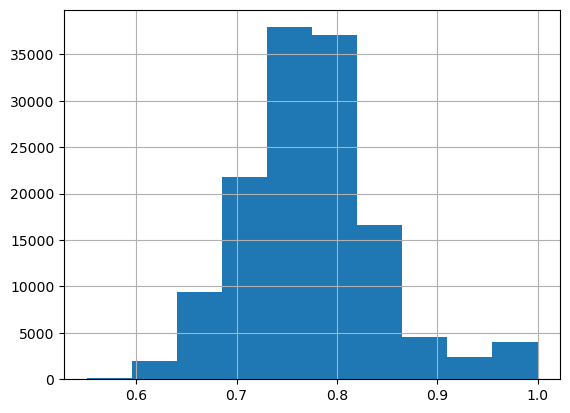

In [41]:
# average rate of missing features across all patients is about 0.75
X[feature_sets['labs'].tolist()].isna().mean(axis=1).hist()

In [43]:
# TODO: Let's just look at single variable differences for now. For each of
# ['age', 'ethnicity', 'gender', 'hospital_numbedscategory'], are the patients that have
# >80% missing labs different from those with <70% missing labs? Feel free to change the thresholds.

In [ ]:
# TODO: Reflect: If we removed all patients with highly missing labs, or imputed their lab values,
# what effect might this have on our ML prediciton model? 

# Q3: Training on only fully observed data 
Next we will test if restricting our training data to patients with more complete records (=low missingness in their data) can introduce selection bias into our mortality prediction model. 

Ideally, we would use a model trained on the fully observed dataset as the "best case baseline" and compare that model to one trained on data with low missingness levels. However, we don't have fully observed data here $^{[1]}$. Because we do not assume access to a ground-truth test distribution, we compare models under the following two settings : 

1. A "selected-sample" model, trained only on patients with relatively complete data (=low rates of missingness)
2. An "all-patients" model, trained on the full training set. 

(Note we will need to use imputation to handle missing values in both settings. For now, let's use mean imputation and we'll later explore other methods.) 

Your todo is to evaluate both models on the same held-out test set. (You could even choose to stratify the held-out test set by rates of missing data)


$^{[1]}$ Researchers studying missingness will often circumvent this issue by using simulated / synthetic data.

In [ ]:
# TODO: evaluate both models on the same held-out test set. You can choose to use all of X
# or a subset of features.


In [ ]:
# TODO: Reflect. 
# - Does training only on well-documented patients improve apparent performance?
# - Does it hurt generalization to patients with sparse records?
# - Does missingness act like a selection mechanism that changes which population the model is trained on?


# Q4: Imputation strategies 

So far, we used simple mean imputation to handle missing features. However, there are many other commonly used imputation strategies, each making different assumptions about the data.

Some examples include:
- Median imputation (more robust to outliers than mean)
- K-nearest neighbors (KNN) imputation, which fills in missing values using similar patients
- Model-based imputation (e.g., regression), where missing values are predicted from other features
- Adding missingness indicators, where we explicitly include whether a value was missing as a feature
- Dropping features or patients with high missingness (complete-case analysis)

Each of these approaches implicitly assumes something about why the data is missing (e.g., MCAR, MAR, or MNAR), and may affect both model performance and bias.


In [ ]:
# TODO: Try different imputation strategies, and see if model performance on mortality prediction changes. 
# Do certain subgroups of patients benefit from different strategies? 


In [ ]:
# TODO: Reflect:
# - Which imputation strategy do you think is most appropriate for this dataset, and why?
# - Can imputation introduce bias, even if it improves accuracy?